In [131]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis

from sklearn.model_selection import train_test_split
from sksurv.preprocessing import OneHotEncoder
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import statsmodels.api as sm
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)


In [119]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_df = pp.elimnation_zeros(df_mRNA_transformed, "Hugo_Symbol")

df_esr1 = pp.gene_to_long(clean_df,"ESR1")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Max of zeros per row in the dataset: 4575
Avg of zeros per row in the dataset: 2911.273838630807
Median of zeros per row in the dataset: 2866.5
Min of zeros per row in the dataset: 0
After the 0 elimination: 454


In [120]:
df = df_esr1.merge(df_clinical_keep, on="Sample ID", how="inner")


status = df["Overall Survival Status"].astype(str).str.strip()
df["event"] = status.str.contains("DECEASED", na=False) 
df = df.dropna(subset=["Overall Survival (Months)"])


X = df[["expression"]]
Y_surv = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df
)

In [121]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_surv, train_size=0.80, test_size=0.20, random_state=42
)

In [122]:
cox_lasso.fit(X_train, Y_train)

CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0)

In [123]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

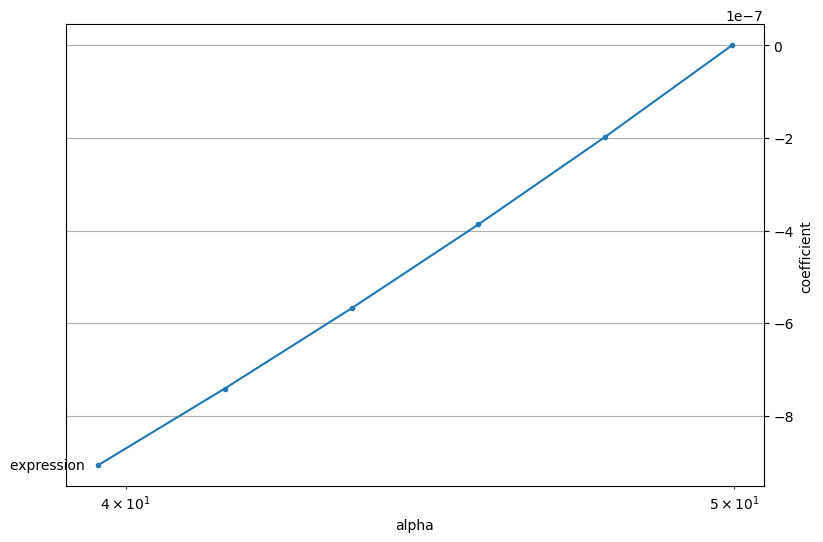

In [124]:
coefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))

plot_coefficients(coefficient_lasso, n_highlight=5)

In [125]:
cox_lasso.predict(X_test)

array([-0.0143762 , -0.00851764,  0.00310551,  0.00303053, -0.0101163 ,
       -0.01348776,  0.00283367, -0.01181977, -0.00333662, -0.0004764 ,
       -0.00169082, -0.00143879, -0.00317633,  0.00808164,  0.00736347,
       -0.00471395,  0.00470747, -0.00140942, -0.05712376, -0.0019717 ,
        0.00817577,  0.00599434,  0.00762379, -0.01472298,  0.00823738,
        0.00804928, -0.00096739,  0.00624099, -0.00530753, -0.02110488,
       -0.0264719 , -0.00364577,  0.0077856 , -0.01459936,  0.00251847,
       -0.00973191,  0.00276234, -0.01536184,  0.00342087,  0.00153399,
       -0.00027118,  0.00247669,  0.00034919, -0.01378532, -0.00769514,
        0.00819148, -0.01277746,  0.0037725 ,  0.00748452, -0.00023812,
        0.00820232,  0.00823585,  0.00358035, -0.02707717,  0.00119612,
        0.00569993,  0.00816146,  0.00460915,  0.00736567, -0.0043135 ,
        0.00286772, -0.00054756, -0.01907692,  0.00535508, -0.00846794,
        0.00825603,  0.00391001,  0.00824858,  0.00821433,  0.00

In [126]:
alphas = 10.0 ** np.linspace(-4, 4, 50)
coefficients = {}

cph = CoxPHSurvivalAnalysis()
for alpha in alphas:
    cph.set_params(alpha=alpha)
    cph.fit(X_train, Y_train)
    key = round(alpha, 5)
    coefficients[key] = cph.coef_

coefficients = pd.DataFrame.from_dict(coefficients).rename_axis(index="feature", columns="alpha").set_index(X_train.columns)

In [127]:
cph.predict(X_test)

array([-1.11913345e-01, -8.29724822e-02, -2.55550245e-02, -2.59254334e-02,
       -9.08697688e-02, -1.07524525e-01, -2.68978647e-02, -9.92847531e-02,
       -5.73786409e-02, -4.32493769e-02, -4.92485410e-02, -4.80035186e-02,
       -5.65868129e-02, -9.73298147e-04, -4.52104017e-03, -6.41825361e-02,
       -1.76414387e-02, -4.78584334e-02, -3.23083008e-01, -5.06360425e-02,
       -5.08319931e-04, -1.12844306e-02, -3.23505188e-03, -1.13626371e-01,
       -2.03960278e-04, -1.13316913e-03, -4.56748358e-02, -1.00659733e-02,
       -6.71147772e-02, -1.45152479e-01, -1.71665141e-01, -5.89058108e-02,
       -2.43573192e-03, -1.13015713e-01, -2.84549337e-02, -8.89708787e-02,
       -2.72502609e-02, -1.16782328e-01, -2.39971649e-02, -3.33182253e-02,
       -4.22355906e-02, -2.86613178e-02, -3.91710175e-02, -1.08994400e-01,
       -7.89093770e-02, -4.30719059e-04, -1.04015682e-01, -2.22601528e-02,
       -3.92305501e-03, -4.20723103e-02, -3.77170724e-04, -2.11507789e-04,
       -2.32093594e-02, -

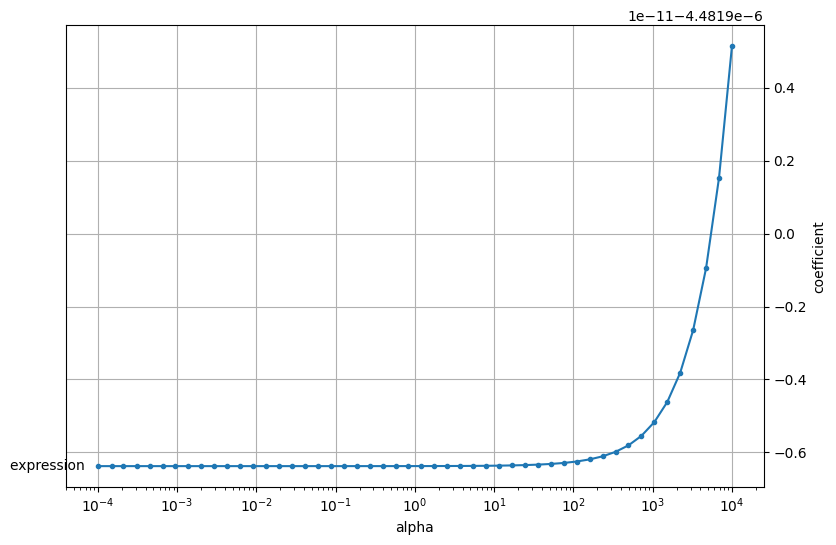

In [128]:
plot_coefficients(coefficients, n_highlight=5)

In [138]:
df_life_line = df[["expression", "event", "Overall Survival (Months)"]]

In [141]:

cph_Cox = CoxPHFitter()
cph_Cox.fit(df_life_line,event_col="event", duration_col="Overall Survival (Months)")

cph_Cox.print_summary()
cph_Cox.predict_median(df_life_line)

<lifelines.CoxPHFitter: fitted with 451 total observations, 389 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 451
number of events observed = 62
   partial log-likelihood = -297.04
         time fit was run = 2026-03-06 17:13:13 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
expression -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

            cmp to     z    p  -log2(p)
covariate                              
expression    0.00 -0.26 0.80      0.33
---
Concordance = 0.54
Partial AIC = 596.09
log-likelihood ratio test = 0.07 on 1 df
-log2(p) of ll-ratio test = 0.33

0      130.06
1      130.06
2      130.06
3      130.06
4      130.06
        ...  
447    128.98
448    128.98
449    128.98
450    130.06
451    128.98
Name: 0.5, Length: 451, dtype: float64